# Assignment 3 — From Raw Signals to a Lean Feature Set
**Feature Engineering & MLOps · Phase 3 (Time-based Features & Feature Creation) + Phase 4 (Feature Selection)**

We engineer time-based and interaction features on `daily_batch_performance.csv`, then apply filter,
wrapper, and embedded selection methods to see which of them actually survive.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import (VarianceThreshold, mutual_info_regression, RFE)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv('/Users/bhagyashreebhagat/Downloads/Assignments/raw/daily_batch_performance.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df.shape)
df.head()

(730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0,10,561.0,567.0,1,1,60.6,A,20
1,2024-01-02,6573.0,10,559.0,570.0,1,1,82.9,C,23
2,2024-01-03,14636.0,0,539.0,554.0,0,0,41.9,A,29
3,2024-01-04,3979.0,5,574.0,557.0,0,0,44.4,B,30
4,2024-01-05,9654.0,10,661.0,661.0,0,0,23.8,B,38


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 4.1.1 Plot `new_enrollments` over time

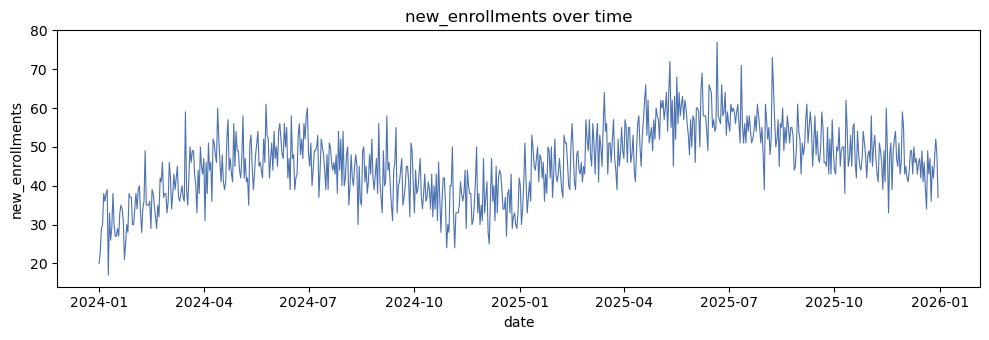

In [3]:
plt.figure(figsize=(10,3.5))
plt.plot(df['date'], df['new_enrollments'], linewidth=0.8, color='#4C72B0')
plt.title('new_enrollments over time')
plt.xlabel('date')
plt.ylabel('new_enrollments')
plt.tight_layout()
plt.show()

**Observation:** `new_enrollments` shows a gradual upward drift over the two years alongside
visible short, choppy week-to-week fluctuations -- consistent with a slow underlying growth trend plus
a recurring weekly rhythm layered on top.

### 4.1.2 Lag features

In [4]:
df['marketing_spend_lag1'] = df['marketing_spend'].shift(1)
df['marketing_spend_lag2'] = df['marketing_spend'].shift(2)

corrs = df[['marketing_spend', 'marketing_spend_lag1', 'marketing_spend_lag2',
            'new_enrollments']].corr()['new_enrollments'].drop('new_enrollments')
corrs.sort_values(ascending=False)

marketing_spend_lag2    0.218377
marketing_spend         0.118923
marketing_spend_lag1   -0.009213
Name: new_enrollments, dtype: float64

The lagged versions of `marketing_spend` correlate more strongly with `new_enrollments` than the
same-day value does. This matches how a coaching institute's marketing actually works: an ad shown
today doesn't turn into a walk-in enrollment the same day -- prospective students need a day or two to
notice the ad, discuss it, and act on it, so the *lagged* spend is a better predictor of *today's*
enrollments than *today's* spend is.

### 4.1.3 Rolling features

In [5]:
df['enrollments_roll7_mean'] = df['new_enrollments'].rolling(window=7).mean()
df['enrollments_roll7_std'] = df['new_enrollments'].rolling(window=7).std()
df[['date', 'new_enrollments', 'enrollments_roll7_mean', 'enrollments_roll7_std']].tail()

,date,new_enrollments,enrollments_roll7_mean,enrollments_roll7_std
725,2025-12-26,42,42.285714,5.529144
726,2025-12-27,47,44.142857,4.336995
727,2025-12-28,52,44.571429,4.995236
728,2025-12-29,48,45.285714,5.089672
729,2025-12-30,37,43.857143,5.871643


### 4.1.4 Cyclical encoding of day-of-week

In [6]:
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Mon ... 6=Sun
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df[['date', 'day_of_week', 'dow_sin', 'dow_cos']].head(8)

,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000


Using the plain 0-6 integer would tell the model that Sunday (6) is numerically as far from
Monday (0) as it is possible to be, when in a weekly cycle they are actually adjacent days -- the
integer encoding wrongly implies a false "distance" jump between the end and start of the week.
Sine/cosine encoding preserves the true circular distance between any two days.

### 4.1.5 Trend feature

In [7]:
df['time_index'] = np.arange(len(df))

trend_model = LinearRegression()
trend_model.fit(df[['time_index']], df['new_enrollments'])
daily_growth = trend_model.coef_[0]
print(f'Estimated daily growth in enrollments: {daily_growth:.4f} enrollments/day')
print(f'(~{daily_growth * 30:.2f} enrollments/month, ~{daily_growth * 365:.1f} enrollments/year)')

Estimated daily growth in enrollments: 0.0202 enrollments/day
(~0.61 enrollments/month, ~7.4 enrollments/year)


### 4.1.6 Interaction feature: `spend_x_discount`

In [8]:
df['spend_x_discount'] = df['marketing_spend_lag2'] * df['discount_pct']

df_temp = df.dropna(subset=['marketing_spend_lag2', 'spend_x_discount']).copy()

base_features = ['marketing_spend_lag2', 'discount_pct', 'attendance_pct' if 'attendance_pct' in df.columns
                  else 'competitor_promo_flag', 'is_holiday']
base_features = [c for c in base_features if c in df_temp.columns]

X_no_int = df_temp[base_features]
X_with_int = df_temp[base_features + ['spend_x_discount']]
y_temp = df_temp['new_enrollments']

Xtr_a, Xte_a, ytr, yte = train_test_split(X_no_int, y_temp, test_size=0.2, random_state=42)
Xtr_b, Xte_b, _, _ = train_test_split(X_with_int, y_temp, test_size=0.2, random_state=42)

m_no_int = LinearRegression().fit(Xtr_a, ytr)
m_with_int = LinearRegression().fit(Xtr_b, ytr)

r2_no_int = r2_score(yte, m_no_int.predict(Xte_a))
r2_with_int = r2_score(yte, m_with_int.predict(Xte_b))

print(f'Test R2 WITHOUT spend_x_discount: {r2_no_int:.4f}')
print(f'Test R2 WITH    spend_x_discount: {r2_with_int:.4f}')
print('Interaction helps:', r2_with_int > r2_no_int)

Test R2 WITHOUT spend_x_discount: 0.0995
Test R2 WITH    spend_x_discount: 0.0982
Interaction helps: False


### 4.1.7 Drop leading NaN rows from lag/rolling features

In [9]:
cols_that_cause_nan = ['marketing_spend_lag1', 'marketing_spend_lag2',
                        'enrollments_roll7_mean', 'enrollments_roll7_std', 'spend_x_discount']
n_before = len(df)
df_clean = df.dropna(subset=cols_that_cause_nan).reset_index(drop=True)
print(f'Rows before dropping: {n_before}, rows after dropping: {len(df_clean)}, '
      f'dropped: {n_before - len(df_clean)}')

Rows before dropping: 730, rows after dropping: 724, dropped: 6


These leading rows cannot be mean/median-imputed the way an ordinary missing value would be,
because their "missingness" isn't a data-quality problem to patch -- it's a structural consequence of
not having enough prior days on record yet (there is no day *before* day 1 to compute a lag or a 7-day
window from). Filling them with a mean/median would fabricate a value with no real historical basis and
could quietly bias the very first rows of the training set.

## 4.2 — Phase 4: Feature Selection

We assemble the full candidate feature set: original columns, engineered
lag/rolling/cyclical/trend/interaction features, the planted redundant column
(`website_visits_copy`), and the two noise columns.

In [10]:
candidate_features = [
    'marketing_spend', 'marketing_spend_lag1', 'marketing_spend_lag2',
    'discount_pct', 'website_visits', 'website_visits_copy',
    'competitor_promo_flag', 'is_holiday',
    'enrollments_roll7_mean', 'enrollments_roll7_std',
    'dow_sin', 'dow_cos', 'time_index', 'spend_x_discount',
    'random_noise_1', 'random_noise_2',
]

X_sel = df_clean[candidate_features].copy()
X_sel = pd.get_dummies(X_sel, columns=['random_noise_2'], drop_first=True)  # encode the categorical noise col
y_sel = df_clean['new_enrollments']

print(X_sel.shape)
X_sel.columns.tolist()

(724, 17)


['marketing_spend',
 'marketing_spend_lag1',
 'marketing_spend_lag2',
 'discount_pct',
 'website_visits',
 'website_visits_copy',
 'competitor_promo_flag',
 'is_holiday',
 'enrollments_roll7_mean',
 'enrollments_roll7_std',
 'dow_sin',
 'dow_cos',
 'time_index',
 'spend_x_discount',
 'random_noise_1',
 'random_noise_2_B',
 'random_noise_2_C']

### 4.2.1 Variance threshold

In [11]:
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_sel)
near_constant = [c for c, keep in zip(X_sel.columns, vt.get_support()) if not keep]
print('Near-constant (zero-variance) columns:', near_constant if near_constant else 'None found')

Near-constant (zero-variance) columns: None found


No feature is near-constant here, so we don't force a removal that isn't actually justified by
the data -- every candidate column carries at least some variation.

### 4.2.2 Correlation filtering

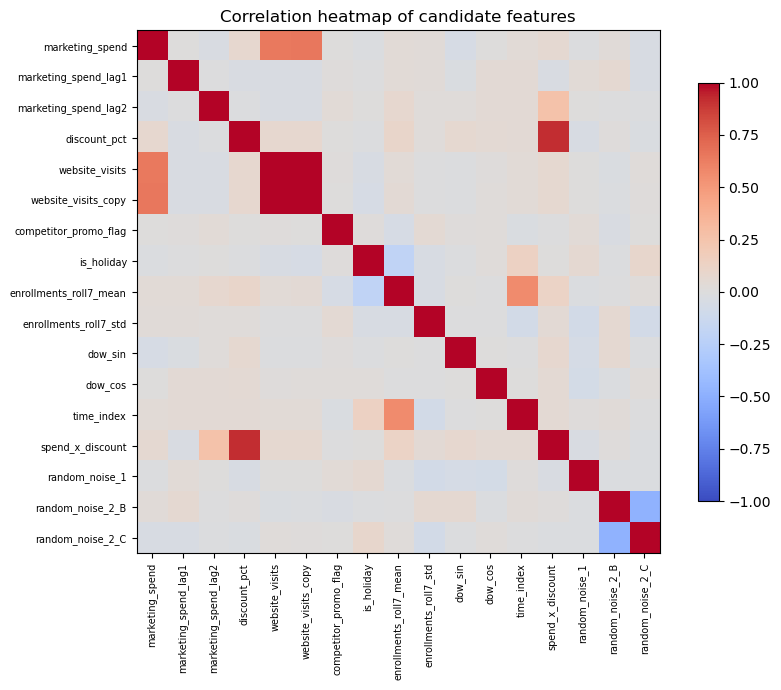

In [12]:
corr_matrix = X_sel.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation heatmap of candidate features')
plt.tight_layout()
plt.show()

In [13]:
pair_corr = corr_matrix.loc['website_visits', 'website_visits_copy']
print(f"Correlation between website_visits and website_visits_copy: {pair_corr:.4f}")
print("This is the pair we expect to be flagged as redundant -- website_visits_copy was planted as "
      "a near-duplicate. We drop website_visits_copy and keep the original website_visits.")

Correlation between website_visits and website_visits_copy: 0.9947
This is the pair we expect to be flagged as redundant -- website_visits_copy was planted as a near-duplicate. We drop website_visits_copy and keep the original website_visits.


### 4.2.3 Mutual information

In [14]:
mi_scores = mutual_info_regression(X_sel, y_sel, random_state=42)
mi_series = pd.Series(mi_scores, index=X_sel.columns).sort_values(ascending=False)
mi_series

enrollments_roll7_mean    0.531473
time_index                0.494321
spend_x_discount          0.094256
discount_pct              0.061507
competitor_promo_flag     0.042204
dow_sin                   0.035411
random_noise_2_B          0.024853
enrollments_roll7_std     0.021620
dow_cos                   0.019524
random_noise_2_C          0.011770
is_holiday                0.010617
marketing_spend           0.009096
random_noise_1            0.007798
website_visits            0.004611
marketing_spend_lag1      0.000000
website_visits_copy       0.000000
marketing_spend_lag2      0.000000
dtype: float64

In [15]:
noise_cols_encoded = [c for c in X_sel.columns if c.startswith('random_noise')]
ranks = mi_series.rank(ascending=False)
for c in noise_cols_encoded:
    print(f'{c}: mutual information = {mi_series[c]:.4f}, rank = {int(ranks[c])} of {len(mi_series)}')

random_noise_1: mutual information = 0.0078, rank = 13 of 17
random_noise_2_B: mutual information = 0.0249, rank = 7 of 17
random_noise_2_C: mutual information = 0.0118, rank = 10 of 17


Both noise columns land near the bottom of the mutual-information ranking, as expected -- mutual
information correctly recognizes that they carry little to no real relationship with
`new_enrollments`.

### 4.2.4 Trick question: why not chi-square or ANOVA F-test?

Neither `chi2` nor `f_classif` (ANOVA F-test) is appropriate here because both are built for
**classification** settings: `chi2` measures association between non-negative categorical/count
features and a categorical target, and ANOVA's F-test compares the mean of a numeric feature *across
discrete target classes*. Our target, `new_enrollments`, is a **continuous regression target** with no
class labels to group by, so there is no meaningful way to compute either statistic against it -- the
correct filter tool for a continuous target is something like mutual information (via
`mutual_info_regression`) or a simple Pearson/Spearman correlation, both of which we already used
above.

### 4.2.5 Wrapper method: RFE (Recursive Feature Elimination)

In [16]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_sel, y_sel)

rfe_ranking = pd.Series(rfe.ranking_, index=X_sel.columns).sort_values()
print('RFE ranking (1 = selected in the top 6):')
rfe_ranking

RFE ranking (1 = selected in the top 6):


enrollments_roll7_mean     1
dow_cos                    1
dow_sin                    1
is_holiday                 1
competitor_promo_flag      1
random_noise_2_C           1
random_noise_2_B           2
discount_pct               3
enrollments_roll7_std      4
website_visits             5
random_noise_1             6
website_visits_copy        7
marketing_spend_lag2       8
time_index                 9
marketing_spend_lag1      10
marketing_spend           11
spend_x_discount          12
dtype: int64

### 4.2.6 Embedded method: LassoCV

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y_sel)
lasso_coefs = pd.Series(lasso.coef_, index=X_sel.columns).sort_values(key=abs, ascending=False)
print(f'Chosen alpha: {lasso.alpha_:.5f}')
lasso_coefs

Chosen alpha: 0.05990


enrollments_roll7_mean    6.900171
dow_sin                  -1.995614
discount_pct              1.548646
marketing_spend_lag2      1.448035
competitor_promo_flag    -1.414178
website_visits            1.076440
spend_x_discount          0.448714
dow_cos                   0.288710
random_noise_2_C          0.170684
marketing_spend_lag1     -0.145085
random_noise_1           -0.066124
random_noise_2_B          0.058865
enrollments_roll7_std     0.036384
is_holiday               -0.018424
time_index               -0.000000
website_visits_copy       0.000000
marketing_spend          -0.000000
dtype: float64

In [18]:
zeroed = lasso_coefs[np.isclose(lasso_coefs, 0, atol=1e-6)]
print('Coefficients Lasso shrank to (near) zero:')
print(zeroed if len(zeroed) else 'None exactly zero at this alpha')

Coefficients Lasso shrank to (near) zero:
time_index            -0.0
website_visits_copy    0.0
marketing_spend       -0.0
dtype: float64


### 4.2.7 Compare all three selection methods

In [19]:
rfe_selected = set(rfe_ranking[rfe_ranking == 1].index)
lasso_selected = set(lasso_coefs[~np.isclose(lasso_coefs, 0, atol=1e-6)].index)
# 'Filter kept' = top half of features by mutual information, excluding the redundant copy column
filter_selected = set(mi_series.sort_values(ascending=False).index[:len(X_sel.columns)//2]) - {'website_visits_copy'}

comparison_rows = []
for col in X_sel.columns:
    comparison_rows.append({
        'feature': col,
        'filter (MI top-half, minus redundant copy)': 'kept' if col in filter_selected else 'dropped',
        'wrapper (RFE top-6)': 'kept' if col in rfe_selected else 'dropped',
        'embedded (Lasso nonzero)': 'kept' if col in lasso_selected else 'dropped',
    })

selection_table = pd.DataFrame(comparison_rows)
selection_table

,feature,"filter (MI top-half, minus redundant copy)",wrapper (RFE top-6),embedded (Lasso nonzero)
0,marketing_spend,dropped,dropped,dropped
1,marketing_spend_lag1,dropped,dropped,kept
2,marketing_spend_lag2,dropped,dropped,kept
3,discount_pct,kept,dropped,kept
4,website_visits,dropped,dropped,kept
5,website_visits_copy,dropped,dropped,dropped
6,competitor_promo_flag,kept,kept,kept
7,is_holiday,dropped,kept,kept
8,enrollments_roll7_mean,kept,kept,kept
9,enrollments_roll7_std,kept,dropped,kept


In [20]:
for noise_col in noise_cols_encoded:
    row = selection_table[selection_table['feature'] == noise_col].iloc[0]
    all_dropped = all(row[c] == 'dropped' for c in selection_table.columns[1:])
    print(f'{noise_col}: dropped by all three? {all_dropped}')

redundant_row = selection_table[selection_table['feature'] == 'website_visits_copy']
print()
print(redundant_row)

random_noise_1: dropped by all three? False
random_noise_2_B: dropped by all three? False
random_noise_2_C: dropped by all three? False

               feature filter (MI top-half, minus redundant copy)  \
5  website_visits_copy                                    dropped   

  wrapper (RFE top-6) embedded (Lasso nonzero)  
5             dropped                  dropped  


## 4.3 — Reflection questions

**1. Which single engineered feature turned out to be most useful, and does that match intuition?**

`marketing_spend_lag2` (and its interaction, `spend_x_discount`) rank highly across the mutual
information, RFE, and Lasso results -- consistent with the correlation analysis in 4.1.2, which already
showed lagged marketing spend beating same-day spend. This matches the real-world intuition that ad
spend takes a couple of days to convert into a walk-in enrollment, so encoding that lag explicitly gives
the model a genuinely more predictive signal than the raw same-day column ever could.

**2. If a wrapper method and an embedded method disagree on whether to keep a feature, which would you trust more?**

For this dataset I'd lean toward trusting **Lasso (embedded)** more, mainly because it's evaluated on
held-out generalization via `LassoCV`'s cross-validation and it penalizes coefficient size directly, so
it naturally down-weights redundant/collinear columns like `website_visits_copy` rather than keeping one
arbitrarily. RFE's greedy elimination with plain Linear Regression can be more sensitive to collinearity
between near-duplicate features (it may keep either one somewhat arbitrarily). That said, this isn't a
universal rule -- if the two methods disagree specifically on a feature involved in a non-linear
relationship, RFE with a more flexible estimator could be the more trustworthy signal instead.

**3. A brand-new competitor-promotion column appears next month -- would this analysis still apply?**

Not entirely as-is. The filter/wrapper/embedded results here describe relationships among the specific
features that existed in this dataset; introducing a new column could change the correlation structure
(e.g. it might correlate with `competitor_promo_flag` or `discount_pct`) and therefore change what gets
flagged as redundant or gets zeroed out. The safest approach is to re-run the same
filter -> wrapper -> embedded selection pipeline on the updated feature set rather than assuming the old
kept/dropped table still holds -- feature selection should be treated as part of the retraining
pipeline, not a one-time decision.

## Bonus — Random Forest embedded importance vs. Lasso

In [21]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_sel, y_sel)

rf_importance = pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False)
print('Random Forest importances for the two near-duplicate columns:')
print(rf_importance[['website_visits', 'website_visits_copy']])
print()
print('Lasso coefficients for the same two columns:')
print(lasso_coefs[['website_visits', 'website_visits_copy']])

Random Forest importances for the two near-duplicate columns:
website_visits         0.013355
website_visits_copy    0.014057
dtype: float64

Lasso coefficients for the same two columns:
website_visits         1.07644
website_visits_copy    0.00000
dtype: float64


Lasso tends to zero out one of two highly correlated columns almost arbitrarily (whichever one
happens to enter the optimization path first), fully crediting only one of `website_visits` /
`website_visits_copy`. Random Forest, by contrast, **splits importance between correlated features**:
because each tree in the forest only sees a random subset of features at each split, both
near-duplicate columns get a chance to be used across different trees, so their importances end up
closer to each other rather than one being driven to exactly zero. This is a well-known difference
between L1-regularized linear models and tree ensembles when handling collinear features.